In [201]:
import pandas as pd
import seaborn as sns
import re
from tqdm import tqdm
from pathlib import Path
import numpy as np
from joblib import Parallel, delayed

sns.set_style('whitegrid')

In this notebook we evaluate the models on standard benchmarks (MedQA, MedMCQA, MMLU-medicine, MedExpQA). 

Since these are multiple choice questions, the only metric we can compute is accuracy (recall and precision do not mean anything, we are not clasifying), we can only check if the answer was correct or not.

As usual we will put error bars on the answers by bootstrapping. We will possibly compare the performance between some pairs using a permutation test.

In [ ]:
benchmark_name_dict = {
    "medmcqa": "MedMCQA",
    "medqa_test": "MedQA",
    "clinical_knowledge": "MMLU - clinical knowledge",
    "professional_medicine": "MMLU - professional medicine",
    "anatomy": "MMLU - anatomy",
    "medexpqa": "MedExpQA",
}

model_name_dict = {
    "Qwen2.5-3B-Instruct": "Q3B",
    "Qwen2.5-7B-Instruct": "Q7B",
    'NACC-3B':"LUNAR-OS-SCE", 
    'NACC-3B-OS':"LUNAR-SCE", 
    'NACC-3B-SCE':"LUNAR-OS",
    'NACC-3B-OS-SCE':"LUNAR", 
}


def load_answers(dir_path):
    # load all parquet files from the directory, stack them into a pandas datafame
    # Reading only those columns is significantly faster (about 100x) than loading the whole dataframe.
    # Loading everything is very slow because there are extremely long strings (model outputs) in some columns

    fpaths = list(dir_path.rglob("*.parquet"))

    dfs = []

    cols_to_read = ["ID", "ground_truth", "prediction"]

    for fpath in tqdm(fpaths):
        model = fpath.parent.name.split("-", 3)[-1]

        benchmark = fpath.parent.parent.name

        df = pd.read_parquet(fpath, columns=cols_to_read)

        df = df.assign(model=model, benchmark=benchmark)

        df["correct"] = (df["ground_truth"] == df["prediction"]).astype(int)

        dfs.append(df)

    df = pd.concat(dfs)

    df["benchmark"] = df["benchmark"].replace(benchmark_name_dict)

    df["model"] = df["model"].replace(model_name_dict)

    # make these columns Categorical
    group_cols = ["benchmark", "model", "prediction", "ground_truth"]
    for col in group_cols:
        df[col] = pd.Categorical(df[col])

    return df


In [256]:
bench_path = Path('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results/standard_benchmarks')
ans = load_answers(bench_path)

  0%|          | 0/48 [00:00<?, ?it/s]

100%|██████████| 48/48 [00:00<00:00, 98.54it/s] 


In [257]:
ans.sample(3)

,ID,ground_truth,prediction,model,benchmark,correct
8434,d0de8433-05e9-4391-ad03-5b228436ccd5,C,C,LUNAR,MedMCQA,1
5207,1041,D,C,LUNAR-OS-SCE,MedQA,0
332,66,B,B,LUNAR,MMLU - clinical knowledge,1


In [258]:
def _process_group_with_bootstrap_samples(id, group, n_boot, seed):
    """
    Helper function that computes bootstrap samples for accuracy.
    Returns confidence intervals and raw bootstrap samples.
    
    Parameters
    ----------
    id : tuple
        (benchmark, model) identifier for this group
    group : pd.DataFrame
        Subset of data for this benchmark-model combination
    n_boot : int
        Number of bootstrap samples
    seed : int
        Random seed for this group
    
    Returns
    -------
    res_list : list
        List with single dict containing CI results
    bootstrap_samples : dict
        Dictionary with raw bootstrap samples
    """
    benchmark, model = id
    n_samples = len(group)
    
    if n_samples == 0:
        return [], {}
    
    # --- Reproducible RNG per worker ---
    rng = np.random.default_rng(seed)
    
    # Pre-generate all bootstrap indices at once
    bootstrap_indices = rng.integers(0, n_samples, size=(n_boot, n_samples))
    
    # Convert to NumPy array ONCE per group
    correct = group["correct"].to_numpy()
    
    # Compute accuracy for each bootstrap sample
    accuracy_samples = []
    for indices in bootstrap_indices:
        correct_boot = correct[indices]
        accuracy = np.mean(correct_boot)
        accuracy_samples.append(accuracy)
    
    accuracy_samples = np.array(accuracy_samples)
    
    # --- Calculate quantiles ---
    low_idx = int(0.025 * n_boot)
    med_idx = int(0.5 * n_boot)
    high_idx = int(0.975 * n_boot)
    
    partitioned = np.partition(accuracy_samples, [low_idx, med_idx, high_idx])
    
    res_list = [{
        "benchmark": benchmark,
        "model": model,
        "metric": "accuracy",
        "median": partitioned[med_idx],
        "low": partitioned[low_idx],
        "high": partitioned[high_idx],
        "n_questions": n_samples//5
    }]
    
    # Store bootstrap samples
    bootstrap_samples = {
        (benchmark, model, "accuracy"): accuracy_samples
    }
    
    return res_list, bootstrap_samples


def compute_bootstrap_accuracy(df, n_boot=1000, seed=None, n_jobs=-1):
    """
    Compute bootstrap confidence intervals for accuracy grouped by model and benchmark.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with columns: ID, ground_truth, prediction, model, benchmark, correct
    n_boot : int, default=1000
        Number of bootstrap samples
    seed : int, optional
        Random seed for reproducible results
    n_jobs : int, default=-1
        Number of CPU cores to use. -1 means all cores.
    
    Returns
    -------
    results_df : pd.DataFrame
        Results with columns: benchmark, model, metric, median, low, high, n_samples
    bootstrap_samples : dict
        Dictionary mapping (benchmark, model, metric) -> array of bootstrap samples
        
    Examples
    --------
    >>> results_df, boot_samples = compute_bootstrap_accuracy(df, n_boot=1000, seed=42)
    >>> print(results_df)
    """
    
    # --- Setup ---
    main_rng = np.random.default_rng(seed)
    
    df_copy = df.copy()
    group_cols = ["benchmark", "model"]
    
    # Get all groups
    groups = list(df_copy.groupby(group_cols, observed=True))
    
    # Generate a unique seed for each group
    n_groups = len(groups)
    group_seeds = main_rng.integers(0, 2**32, size=n_groups)
    
    # --- Parallel Execution ---
    results_with_samples = Parallel(n_jobs=n_jobs, verbose=0)(
        delayed(_process_group_with_bootstrap_samples)(
            id, 
            group, 
            n_boot, 
            group_seeds[i]
        )
        for i, (id, group) in enumerate(groups)
    )
    
    # --- Collect Results ---
    final_results = []
    all_bootstrap_samples = {}
    
    for res_list, boot_samples in results_with_samples:
        final_results.extend(res_list)
        all_bootstrap_samples.update(boot_samples)
    
    results_df = pd.DataFrame(final_results)
    
    # Sort for easier viewing
    results_df = results_df.sort_values(['benchmark', 'model']).reset_index(drop=True)
    
    return results_df, all_bootstrap_samples

In [259]:
np.random.seed(42)

# Compute bootstrap accuracy
results, bootstrap_samples = compute_bootstrap_accuracy(
    ans, 
    n_boot=1000, 
    seed=42, 
    n_jobs=-1
)

In [260]:
results.head()

,benchmark,model,metric,median,low,high,n_questions
0,MMLU - anatomy,LUNAR,accuracy,0.622222,0.588148,0.654815,135
1,MMLU - anatomy,LUNAR-OS,accuracy,0.614815,0.579259,0.648889,135
2,MMLU - anatomy,LUNAR-OS-SCE,accuracy,0.626667,0.591111,0.665185,135
3,MMLU - anatomy,LUNAR-SCE,accuracy,0.635556,0.601481,0.668148,135
4,MMLU - anatomy,NACC-7B-OS,accuracy,0.711111,0.678519,0.746667,135


In [264]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def plot_bootstrap_accuracy(results_df, model_order=None, figsize=None, 
                            palette="Set2", bar_width=0.8):
    """
    Plot bootstrap accuracy results with error bars, faceted by benchmark.
    
    Parameters
    ----------
    results_df : pd.DataFrame
        DataFrame with columns: benchmark, model, metric, median, low, high, n_questions
    model_order : list, optional
        List specifying the order of models on the x-axis.
        If None, models will be sorted alphabetically.
    figsize : tuple, optional
        Figure size (width, height). If None, automatically determined.
    palette : str or list, optional
        Color palette for the bars. Default is "Set2".
    bar_width : float, optional
        Width of the bars. Default is 0.8.
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure object
    axes : array of matplotlib.axes.Axes
        Array of axes objects
        
    Examples
    --------
    >>> fig, axes = plot_bootstrap_accuracy(results_df, model_order=['gpt4', 'claude', 'llama'])
    >>> plt.tight_layout()
    >>> plt.show()
    """
    
    # Filter to only accuracy metric (in case there are others)
    df = results_df[results_df['metric'] == 'accuracy'].copy()

    df = results_df[results_df['model'].isin(model_order)].copy()
    
    # Determine model order
    if model_order is None:
        model_order = sorted(df['model'].unique())
    
    # Convert model to categorical with specified order
    df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)
    df = df.sort_values('model')
    
    # Get unique benchmarks
    benchmarks = sorted(df['benchmark'].unique())
    n_benchmarks = len(benchmarks)
    
    # Calculate number of rows and columns for facets (wrap at 3 columns)
    n_cols = min(3, n_benchmarks)
    n_rows = int(np.ceil(n_benchmarks / n_cols))
    
    # Determine figure size if not provided
    if figsize is None:
        figsize = (6 * n_cols, 5 * n_rows)
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False, sharex=True, sharey='row', layout='constrained')
    axes = axes.flatten()
    
    # Get colors
    if isinstance(palette, str):
        colors = sns.color_palette(palette, n_colors=len(model_order))
    else:
        colors = palette
    
    # Plot each benchmark
    for idx, benchmark in enumerate(benchmarks):
        ax = axes[idx]
        
        # Filter data for this benchmark
        benchmark_data = df[df['benchmark'] == benchmark].copy()
        
        # Ensure all models are present (even if missing data)
        benchmark_data = benchmark_data.set_index('model').reindex(model_order).reset_index()
        
        # Calculate error bars (distance from median to low/high)
        yerr_low = benchmark_data['median'] - benchmark_data['low']
        yerr_high = benchmark_data['high'] - benchmark_data['median']
        yerr = np.array([yerr_low, yerr_high])
        
        # Create bar plot
        x_pos = np.arange(len(model_order))
        bars = ax.bar(x_pos, benchmark_data['median'], 
                     width=bar_width, 
                     color=colors,
                     edgecolor='black',
                     linewidth=0.5,
                     alpha=1)
        
        # Add error bars
        ax.errorbar(x_pos, benchmark_data['median'], 
                   yerr=yerr,
                   fmt='none',
                   ecolor='black',
                   capsize=5,
                   capthick=1,
                   linewidth=1)

        # Annotate bars with median values (above the error bar)
        for i, (bar, median_val, high_val) in enumerate(zip(bars, benchmark_data['median'], benchmark_data['high'])):
            if pd.notna(median_val) and pd.notna(high_val):  # Only annotate if data exists
                # ax.text(bar.get_x() + bar.get_width()/2., high_val + 0.03,
                ax.text(bar.get_x() + bar.get_width()/2. + 0.05 , 0.03,
                       f'{median_val:.3f}',
                       ha='center', va='bottom',
                       fontsize=9, 
                       rotation=90,
                    #    bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='none', alpha=1))
                )
        
        
        # Customize subplot
        ax.set_xlabel('')
        # ax.set_ylabel('Accuracy', fontsize=10)
        ax.set_title(f'{benchmark}', fontsize=10, pad=10)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(model_order, rotation=90, ha='center')
        # ax.set_ylim(0, 1.0)  
        ax.grid(axis='y', alpha=0.5, linestyle='--')
        ax.set_axisbelow(True)

    # Hide unused subplots
    for idx in range(n_benchmarks, len(axes)):
        axes[idx].set_visible(False)
    
    # plt.tight_layout()

    axes[0].set_ylabel('Accuracy')
    axes[3].set_ylabel('Accuracy')
    
    return fig, axes

In [265]:
model_order = [
    "Q3B",
    "LUNAR-OS-SCE",
    "LUNAR-SCE",
    "LUNAR-OS",
    "LUNAR",
    "Q7B",
    # "NACC-7B-OS",
    # "NACC-7B-OS-SCE",
]

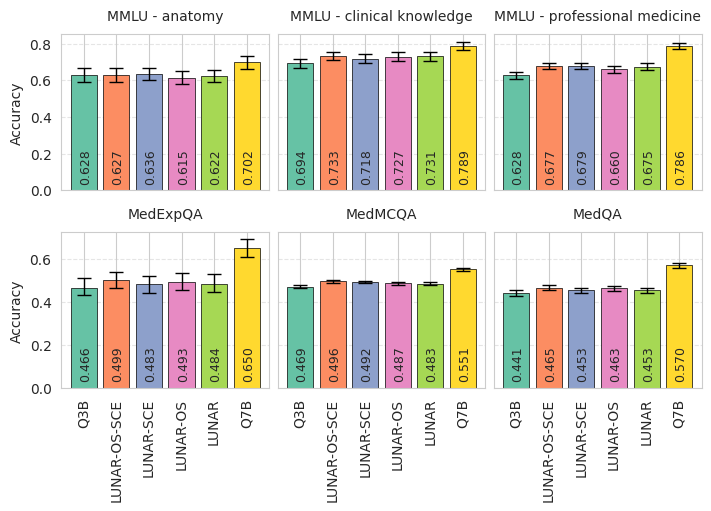

In [266]:
fig, axes = plot_bootstrap_accuracy(
    results, 
    model_order=model_order,
    figsize=(7,5),
    bar_width=0.8
)

In [268]:
fig.savefig('../figures/benchmarks.pdf',bbox_inches='tight')